Final Project Third FFNN Architecture <br>
Hidden Layers = 3 <br>
Neurons: <br>
    nn.Linear(29, 15) <br>
    nn.ReLU() <br>
    nn.Linear(15, 40) <br>
    nn.ReLU() <br>
    nn.Linear(40, 25) <br>
    nn.ReLU() <br>
    nn.Linear(25, 1) <br>
    nn.Sigmoid()) <br>

Epochs: 2000 <br>   

Optimizer: Adam <br>
lr: 1e-4

In [295]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import time

In [296]:
# capture start time
start_time = time.time()

In [297]:
data = pd.read_csv('../content/sample_data/project_data.csv')

In [298]:
# Reviewing data values in dataset
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,meal_plan_1,0,room_type1,224,2017-10-02,offline,0,0,0,65.00,0,not_canceled
1,INN00002,2,0,2,3,not_selected,0,room_type1,5,2018-11-06,online,0,0,0,106.68,1,not_canceled
2,INN00003,1,0,2,1,meal_plan_1,0,room_type1,1,2018-02-28,online,0,0,0,60.00,0,canceled
3,INN00004,2,0,0,2,meal_plan_1,0,room_type1,211,2018-05-20,online,0,0,0,100.00,0,canceled
4,INN00005,2,0,1,1,not_selected,0,room_type1,48,2018-04-11,online,0,0,0,94.50,0,canceled


In [299]:
# Preprocess/convert arrival_date column to season:
data['arrival_date'] = pd.to_datetime(data['arrival_date'])
data['month_number'] = data['arrival_date'].dt.month

def month_to_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    else:
        return 'Invalid Month'

data['season'] = data['month_number'].apply(month_to_season)
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,month_number,season
0,INN00001,2,0,1,2,meal_plan_1,0,room_type1,224,2017-10-02,offline,0,0,0,65.00,0,not_canceled,10,Autumn
1,INN00002,2,0,2,3,not_selected,0,room_type1,5,2018-11-06,online,0,0,0,106.68,1,not_canceled,11,Autumn
2,INN00003,1,0,2,1,meal_plan_1,0,room_type1,1,2018-02-28,online,0,0,0,60.00,0,canceled,2,Winter
3,INN00004,2,0,0,2,meal_plan_1,0,room_type1,211,2018-05-20,online,0,0,0,100.00,0,canceled,5,Spring
4,INN00005,2,0,1,1,not_selected,0,room_type1,48,2018-04-11,online,0,0,0,94.50,0,canceled,4,Spring


In [300]:
# Remove unneeded columns
data = data.drop(['Booking_ID', 'month_number', 'arrival_date'], axis=1)

In [301]:
# Change order of columns, putting numeric 1st
data = data.iloc[:, [0, 1, 2, 3, 7, 10, 11, 12, 13, 4, 5, 6, 8, 9, 14, 15]]

In [302]:
# Reviewing data values in dataset
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,type_of_meal_plan,required_car_parking_space,room_type_reserved,market_segment_type,repeated_guest,booking_status,season
0,2,0,1,2,224,0,0,65.00,0,meal_plan_1,0,room_type1,offline,0,not_canceled,Autumn
1,2,0,2,3,5,0,0,106.68,1,not_selected,0,room_type1,online,0,not_canceled,Autumn
2,1,0,2,1,1,0,0,60.00,0,meal_plan_1,0,room_type1,online,0,canceled,Winter
3,2,0,0,2,211,0,0,100.00,0,meal_plan_1,0,room_type1,online,0,canceled,Spring
4,2,0,1,1,48,0,0,94.50,0,not_selected,0,room_type1,online,0,canceled,Spring


In [303]:
# Remove existing column where target will be; identify target column
X = data.drop('booking_status', axis=1)
target_label = data['booking_status']

# Encode target with LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(target_label)

# Split dataset into training and test sets (75:25 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=123)  # split into train and test sets

In [304]:
# One Hot Encode using scikit-learn OneHotEncoder on the training set
encoder = OneHotEncoder(handle_unknown='error')
encoder.fit(X_train[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']])  # columns to fit

encoded_df = pd.DataFrame(encoder.transform(X_train[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']]).toarray(),
                          columns=encoder.get_feature_names_out(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']))

X_train = pd.concat([X_train.drop(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season'], axis=1).reset_index(drop=True), encoded_df], axis=1)


In [305]:
# Perform scaling using scikit-learn StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [306]:
# One Hot Encode using scikit-learn OneHotEncoder on the test set
encoded_df = pd.DataFrame(encoder.transform(X_test[['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']]).toarray(),
                          columns=encoder.get_feature_names_out(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season']))
X_test = pd.concat([X_test.drop(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'season'], axis=1).reset_index(drop=True), encoded_df], axis=1)

# Perform scaling using same scaler identified in the training set scaling process
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_test.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'lead_time', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'required_car_parking_space',
       'repeated_guest', 'type_of_meal_plan_meal_plan_1',
       'type_of_meal_plan_meal_plan_2', 'type_of_meal_plan_meal_plan_3',
       'type_of_meal_plan_not_selected', 'room_type_reserved_room_type1',
       'room_type_reserved_room_type2', 'room_type_reserved_room_type3',
       'room_type_reserved_room_type4', 'room_type_reserved_room_type5',
       'room_type_reserved_room_type6', 'room_type_reserved_room_type7',
       'market_segment_type_aviation', 'market_segment_type_complementary',
       'market_segment_type_corporate', 'market_segment_type_offline',
       'market_segment_type_online', 'season_Autumn', 'season_Spring',
       'season_Summer', 'season_Winter'],
      dtype='object')

In [307]:
# Add PCA here
principal = PCA()
principal.fit(X_train_scaled.iloc[:, 0:8])

PCA()

In [308]:
principal.explained_variance_

array([1.68219032, 1.34431931, 1.26706411, 0.984672  , 0.91644531,
       0.77952427, 0.51976703, 0.506312  ])

In [309]:
principal.explained_variance_ratio_

array([0.21026605, 0.16803373, 0.15837719, 0.12307947, 0.11455145,
       0.09743695, 0.06496849, 0.06328667])

Text(0, 0.5, 'Explained Variance')

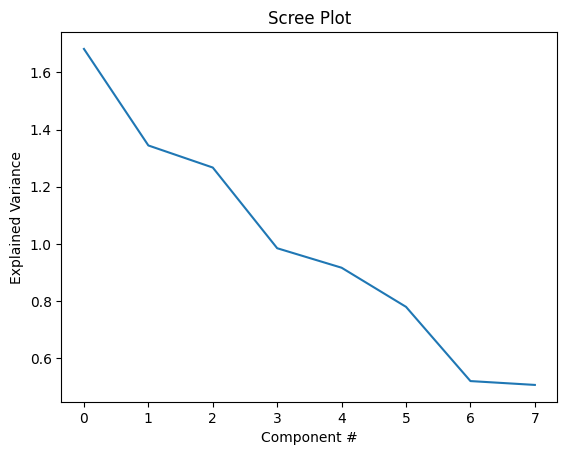

In [310]:
plt.plot(principal.explained_variance_)
plt.title('Scree Plot')
plt.xlabel('Component #')
plt.ylabel('Explained Variance')

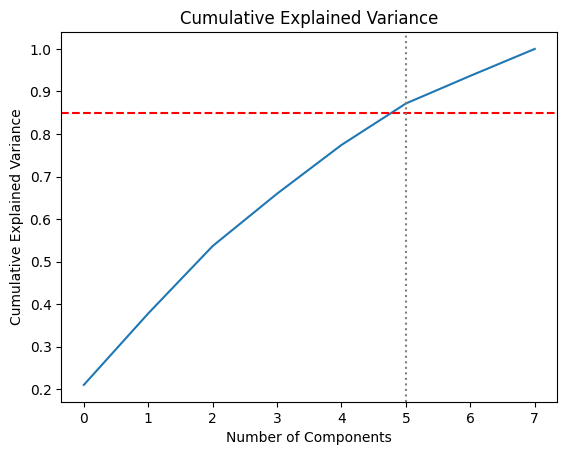

Explained variance ratio for each component
[0.21026605 0.16803373 0.15837719 0.12307947 0.11455145 0.09743695
 0.06496849 0.06328667]


In [311]:
# cumulative explained variance
cumulative_variance = np.cumsum(principal.explained_variance_ratio_)
plt.plot(cumulative_variance)
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle='--')
plt.axvline(x=5, color='grey', linestyle='dotted')
plt.show()

print("Explained variance ratio for each component")
print(principal.explained_variance_ratio_)

In [312]:
# take 1st 6 ?
# start with original set of numeric columns
# project observations onto PCs
latent_features = pd.DataFrame(principal.transform(X_train_scaled.iloc[:, 0:8]))

In [313]:
# take first 6 col from latent_features
X_train_PCA = pd.concat([latent_features.iloc[:, 0:6].reset_index(drop=True), X_train_scaled.iloc[:, 8:].reset_index(drop=True)], axis=1)

In [314]:
# repeat on test set
latent_features = pd.DataFrame(principal.transform(X_test_scaled.iloc[:, 0:8]))
X_test_PCA = pd.concat([latent_features.iloc[:, 0:6].reset_index(drop=True), X_test_scaled.iloc[:, 8:].reset_index(drop=True)], axis=1)

In [315]:
# create tensors from PCA values
X_train_tensor = torch.tensor(X_train_PCA.values, dtype=torch.float32)
y_train_tensor = torch.as_tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_PCA.values, dtype=torch.float32)
y_test_tensor = torch.as_tensor(y_test, dtype=torch.float32)

In [316]:
# Divide training set into smaller training & validation datasets (80:20 ratio)
n_samples = X_train_tensor.shape[0]
n_val = int(0.2 * n_samples)
shuffled_indices = torch.randperm(n_samples)
train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]
train_indices, val_indices

# Assign values to tensor from indices
X_tr = X_train_tensor[train_indices]
y_tr = y_train_tensor[train_indices]
X_val = X_train_tensor[val_indices]
y_val = y_train_tensor[val_indices]

In [317]:
# Define feedforward neural network #1
# Note 3 hidden layers, 3 activation functions
# Sigmoid function used for output layer

seq_model = nn.Sequential(
    nn.Linear(29, 15),
    nn.ReLU(),
    nn.Linear(15, 40),
    nn.ReLU(),
    nn.Linear(40, 25),
    nn.ReLU(),
    nn.Linear(25, 1),
    nn.Sigmoid())
seq_model

Sequential(
  (0): Linear(in_features=29, out_features=15, bias=True)
  (1): ReLU()
  (2): Linear(in_features=15, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=25, bias=True)
  (5): ReLU()
  (6): Linear(in_features=25, out_features=1, bias=True)
  (7): Sigmoid()
)

In [318]:
# Establish empty arrays to capture losses for plotting later
train_losses = []
validation_losses = []

In [319]:
# Define the training loop
def training_loop(n_epochs, optimizer, model, loss_fn, X_tr, X_val, y_tr, y_val):
    for epoch in range(1, n_epochs + 1):
        X_tr_p = model(X_tr)
        loss_train = loss_fn(X_tr_p, y_tr.unsqueeze(1))
        train_losses.append(loss_train.item())  # for plotting purposes

        X_val_p = model(X_val)
        loss_val = loss_fn(X_val_p, y_val.unsqueeze(1))
        validation_losses.append(loss_val.item())  # for plotting purposes

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 250 == 0:
            print(f"Epoch {epoch}, Training loss {loss_train.item():.4f},"f" Validation loss {loss_val.item():.4f}")

In [320]:
# Ran the training loop for 2000 epochs and used the Adam optimizer, learn rate 4.
optimizer = optim.Adam(seq_model.parameters(), lr=1e-4)
training_loop(
    n_epochs = 2000,
    optimizer = optimizer,
    model = seq_model,
    loss_fn = nn.BCELoss(),
    X_tr = X_tr,
    X_val = X_val,
    y_tr = y_tr,
    y_val = y_val)

Epoch 1, Training loss 0.6702, Validation loss 0.6685
Epoch 250, Training loss 0.6164, Validation loss 0.6128
Epoch 500, Training loss 0.5074, Validation loss 0.5104
Epoch 750, Training loss 0.4403, Validation loss 0.4518
Epoch 1000, Training loss 0.4159, Validation loss 0.4306
Epoch 1250, Training loss 0.4034, Validation loss 0.4201
Epoch 1500, Training loss 0.3941, Validation loss 0.4125
Epoch 1750, Training loss 0.3850, Validation loss 0.4045
Epoch 2000, Training loss 0.3781, Validation loss 0.3986


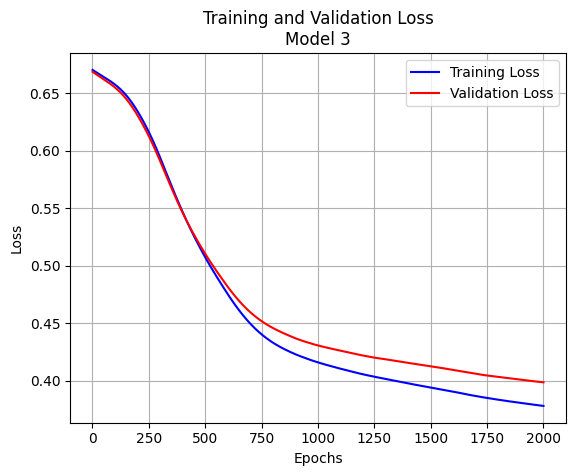

In [321]:
# Plot training and validation loss lines
epochs = range(1, len(train_losses) + 1)
plt.grid()
plt.plot(epochs, train_losses, 'b-', label='Training Loss')
plt.plot(epochs, validation_losses, 'r-', label='Validation Loss')
plt.title('Training and Validation Loss\nModel 3')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [322]:
# Calculate the fitted model predictions for the test set
seq_model(X_test_tensor).detach().numpy()

array([[0.98606956],
       [0.87656236],
       [0.79856807],
       ...,
       [0.96687627],
       [0.04242349],
       [0.40342313]], dtype=float32)

Create a data frame that combines the actual label values and the predicted probabilities of positive class membership.

In [323]:
# Create dataframe that combines actual label vaues vs predicted
# possibilities of a customer cancelling a reserved booking
p_1_actual = pd.DataFrame({'p_1': seq_model(X_test_tensor).detach().numpy().reshape(-1), 'actual': y_test})
p_1_actual.head()

,p_1,actual
0,0.986070,1
1,0.876562,1
2,0.798568,1
3,0.259250,1
4,0.193916,1


In [324]:
# calculate accuracy
from sklearn.metrics import accuracy_score

# Convert probabilities to class predictions using a threshold (e.g., 0.5)
y_pred = (seq_model(X_test_tensor).detach().numpy().reshape(-1) >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8226269315673289


In [325]:
# Compute Confusion Matrix
import pandas as pd
# Convert probabilities to class predictions using a 0.5 threshold
y_pred = (seq_model(X_test_tensor).detach().numpy().reshape(-1) >= 0.5).astype(int)

df_confusion = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
df_confusion

Predicted,0,1
Actual,,
0,1964,965
1,642,5489


Calculate the information needed for the ROC curve.

In [326]:
# Calculation of data to produce an ROC curve
roc_data = pd.DataFrame({'threshold': np.arange(1, -0.01, -0.01), 'fpr': 0.0, 'tpr': 0.0})
for i in np.arange(1, -0.01, -0.01):

    over_threshold = p_1_actual[p_1_actual['p_1'] >= i]

    fp = len(over_threshold[over_threshold['actual']==0])
    actuals_0 = len(p_1_actual[p_1_actual['actual']==0])
    fpr = fp/actuals_0

    roc_data.loc[roc_data['threshold'] == i, 'fpr'] = fpr

    tp = len(over_threshold[over_threshold['actual']==1])
    actuals_1 = len(p_1_actual[p_1_actual['actual']==1])
    tpr = tp/actuals_1

    roc_data.loc[roc_data['threshold'] == i, 'tpr'] = tpr

roc_data

,threshold,fpr,tpr
0,1.000000e+00,0.000000,0.000979
1,9.900000e-01,0.001024,0.110259
2,9.800000e-01,0.003414,0.191812
3,9.700000e-01,0.008194,0.250367
4,9.600000e-01,0.010584,0.298320
...,...,...,...
96,4.000000e-02,0.918744,0.999184
97,3.000000e-02,0.936839,0.999674
98,2.000000e-02,0.970980,0.999837
99,1.000000e-02,0.987368,1.000000


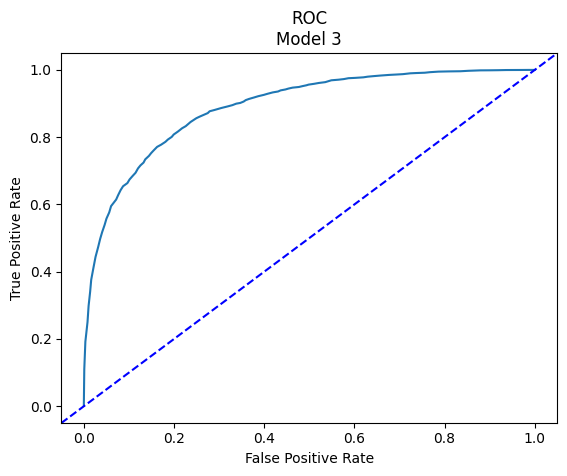

In [327]:
# Plot the ROC curve
# Expecting a curve that approaches top-left corner of graph and then
# curves out to the right
roc = sns.lineplot(x='fpr', y='tpr', data=roc_data)
plt.xlim(-0.05, 1.05)

xlims = roc.get_xlim()
ylims = roc.get_ylim()

min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])

roc.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='blue')

roc.set_xlim(xlims)
roc.set_ylim(ylims)
plt.title('ROC\nModel 3')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

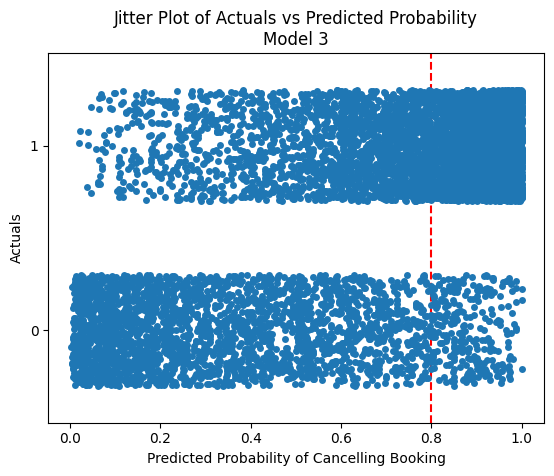

In [328]:
# Plot jitter plot to visualize predicted probabilities of cancelled bookings
# Expecting a balanced class membership
p_1_actual['actual'] = p_1_actual['actual'].astype(str)

# Create a jitter plot using stripplot
sns.stripplot(x='p_1', y='actual', data=p_1_actual, jitter=0.3)

# Customize the plot (optional)
plt.title('Jitter Plot of Actuals vs Predicted Probability\nModel 3')
plt.xlabel('Predicted Probability of Cancelling Booking')
plt.axvline(x=0.80, color='red', linestyle='--')
plt.ylabel('Actuals')

# Display the plot
plt.show()

In [329]:
# Calculate the information needed for the Calibration curve.

calibration_data = pd.DataFrame({'bin_midpoint': np.arange(0.05, 0.96, 0.1),
                                 'observed_event_percentage': 0.0})
for i in np.arange(0.05, 0.96, 0.1):

    in_interval = p_1_actual[(p_1_actual['p_1'] >= (i-0.05)) & (p_1_actual['p_1'] <= (i+0.05))].copy()
    in_interval['actual'] = in_interval['actual'].astype(int)
    num_positive_in_interval = len(in_interval.loc[in_interval['actual'] == 1])
    num_in_interval = len(in_interval)

    oep = num_positive_in_interval/num_in_interval

    calibration_data.loc[calibration_data['bin_midpoint'] == i, 'observed_event_percentage'] = oep

calibration_data

,bin_midpoint,observed_event_percentage
0,0.05,0.047256
1,0.15,0.166667
2,0.25,0.271967
3,0.35,0.368545
4,0.45,0.469636
5,0.55,0.531034
6,0.65,0.683794
7,0.75,0.777487
8,0.85,0.851883
9,0.95,0.966413


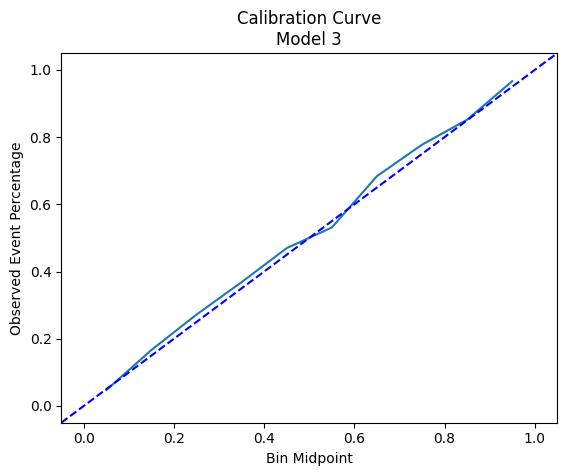

In [330]:
# Plot the Calibration curve.

roc = sns.lineplot(x='bin_midpoint', y='observed_event_percentage'
        , data=calibration_data)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

xlims = roc.get_xlim()
ylims = roc.get_ylim()

min_val = min(xlims[0], ylims[0])
max_val = max(xlims[1], ylims[1])

roc.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='blue')

roc.set_xlim(xlims)
roc.set_ylim(ylims)
plt.title('Calibration Curve\nModel 3')
plt.xlabel('Bin Midpoint')
plt.ylabel('Observed Event Percentage')

plt.show()

In [331]:
# capture end time
end_time = time.time()

# calculate processing time
elapsed_time = end_time - start_time
print(f"Processing time: {elapsed_time:.4f} seconds")

Processing time: 47.3513 seconds
